In [45]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Clientes

In [46]:
df_clientes = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_clientes.csv')

In [47]:
df_clientes

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,714,3,app_android,8.0,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,454,3,app_ios,8.0,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,837,16,app_ios,10.0,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,533,1,app_ios,7.0,False,True,es_MX,True,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15020,USR-15021,56,M,Nuevo León,Monterrey,Secundaria,Empleado,40000,1145,True,...,591,16,app_ios,10.0,False,False,es_MX,False,2,False
15021,USR-15022,34,M,Ciudad de México,CDMX - Miguel Hidalgo,Licenciatura,Empleado,13500,1652,False,...,726,4,app_android,6.0,False,False,es_MX,False,2,False
15022,USR-15023,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empleado,19500,671,True,...,473,1,app_ios,7.0,False,False,es_MX,False,1,False
15023,USR-15024,27,M,Ciudad de México,CDMX - Benito Juárez,Licenciatura,Empleado,4500,434,False,...,614,42,app_android,5.0,False,False,es_MX,False,1,False


In [48]:
df_clientes.columns

Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')

# Productos

In [49]:
df_prod = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_productos.csv')

In [50]:
df_prod.shape

(38909, 13)

In [51]:
df_prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 38909 entries, 0 to 38908
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   producto_id              38909 non-null  str    
 1   user_id                  38909 non-null  str    
 2   tipo_producto            38909 non-null  str    
 3   fecha_apertura           38909 non-null  str    
 4   estatus                  38909 non-null  str    
 5   limite_credito           14317 non-null  float64
 6   saldo_actual             35159 non-null  float64
 7   utilizacion_pct          14317 non-null  float64
 8   tasa_interes_anual       18791 non-null  float64
 9   plazo_meses              4550 non-null   float64
 10  monto_mensualidad        4550 non-null   float64
 11  fecha_ultimo_movimiento  38909 non-null  str    
 12  es_dato_sintetico        38909 non-null  bool   
dtypes: bool(1), float64(6), str(6)
memory usage: 5.9 MB


In [52]:
df_prod.isna().sum()

producto_id                    0
user_id                        0
tipo_producto                  0
fecha_apertura                 0
estatus                        0
limite_credito             24592
saldo_actual                3750
utilizacion_pct            24592
tasa_interes_anual         20118
plazo_meses                34359
monto_mensualidad          34359
fecha_ultimo_movimiento        0
es_dato_sintetico              0
dtype: int64

In [53]:
lista=['tarjeta_credito_hey','tarjeta_credito_garantizada','tarjeta_credito_negocios','credito_personal','credito_auto','credito_nomina']
df_prod.loc[df_prod['tipo_producto'].isin(lista)].shape[0]

14317

In [54]:
lista=['seguro_vida','seguro_compras','cuenta_negocios','inversion_hey','cuenta_debito']
df_prod.loc[df_prod['tipo_producto'].isin(lista)& df_prod['limite_credito'].isna()].shape[0]

24592

Transacciones

In [55]:
df_trans = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_transacciones.csv')

In [56]:
df_trans

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,1,NaN,NaN,SPEI enviado,11,Sunday,False,app_android,False,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,1,NaN,5.69,dep. efvo,7,Saturday,False,app_ios,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,1,NaN,NaN,cobro membresia,1,Friday,False,app_android,True,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,1,NaN,NaN,crg recur,3,Sunday,False,app_ios,True,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,1,NaN,NaN,compra en lnea,15,Thursday,False,app_android,True,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,1,NaN,NaN,COMPRA TRNDA,5,Thursday,False,NaN,True,True


In [57]:
df_prod

,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
2,PRD-00000003,USR-00002,cuenta_debito,2025-04-03,activo,NaN,20712.54,NaN,NaN,NaN,NaN,2025-10-16,True
3,PRD-00000004,USR-00002,tarjeta_credito_hey,2025-07-18,activo,22000.0,6122.60,0.2783,34.08,NaN,NaN,2025-09-15,True
4,PRD-00000005,USR-00003,cuenta_debito,2023-03-26,activo,NaN,3454.65,NaN,NaN,NaN,NaN,2025-09-27,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38904,PRD-00038905,USR-15024,cuenta_debito,2025-04-12,cancelado,NaN,34705.75,NaN,NaN,NaN,NaN,2025-09-02,True
38905,PRD-00038906,USR-15024,tarjeta_credito_garantizada,2025-10-08,activo,10000.0,2032.00,0.2032,44.93,NaN,NaN,2025-11-10,True
38906,PRD-00038907,USR-15025,cuenta_debito,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True
38907,PRD-00038908,USR-15025,cuenta_negocios,2025-07-16,activo,NaN,21770.60,NaN,NaN,NaN,NaN,2025-09-06,True


In [58]:
df_prod.columns

Index(['producto_id', 'user_id', 'tipo_producto', 'fecha_apertura', 'estatus',
       'limite_credito', 'saldo_actual', 'utilizacion_pct',
       'tasa_interes_anual', 'plazo_meses', 'monto_mensualidad',
       'fecha_ultimo_movimiento', 'es_dato_sintetico'],
      dtype='str')

In [59]:
# Tipos de producto y estatus a evaluar
tipos_objetivo = ['seguro_vida', 'seguro_compras', 'cuenta_negocios']
estatus_validos = ['activo', 'cancelado', 'suspendido']

# Filtrar df_productos solo con los estatus relevantes
df_filtrado = df_prod[df_prod['estatus'].isin(estatus_validos)]

# Crear las 3 nuevas columnas en el dataset de clientes
for tipo in tipos_objetivo:
    # Obtener user_ids que tienen ese tipo de producto
    ids_con_producto = df_filtrado[df_filtrado['tipo_producto'] == tipo]['user_id'].unique()
    
    # Agregar columna al dataset de clientes
    df_clientes[tipo] = df_clientes['user_id'].isin(ids_con_producto)

In [60]:
# Estandariza ambos IDs a string y quita espacios

try:
    pou=pd.merge(df_trans,df_clientes,on='user_id',how='left',validate='many_to_one')
    print(f'si funciona {len(pou)}')
except Exception as e:
    print(f'Error: {e}')
    
pou
    

si funciona 802384


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico_y,seguro_vida,seguro_compras,cuenta_negocios
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,10.0,False,True,es_MX,False,2,False,False,False,False
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True


In [61]:
pou_exe=pd.merge(pou,df_prod,on='producto_id',how='left',validate='many_to_one')
pou_exe

,transaccion_id,user_id_x,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,fecha_apertura,estatus_y,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico_y
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,2025-07-09,activo,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,2025-07-09,activo,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True


In [62]:
pou_exe.columns

Index(['transaccion_id', 'user_id_x', 'producto_id', 'fecha_hora',
       'tipo_operacion', 'canal', 'monto', 'comercio_nombre', 'categoria_mcc',
       'ciudad_transaccion', 'estatus_x', 'motivo_no_procesada',
       'intento_numero', 'meses_diferidos', 'cashback_generado',
       'descripcion_libre', 'hora_del_dia', 'dia_semana', 'es_internacional',
       'dispositivo', 'patron_uso_atipico_x', 'es_dato_sintetico_x', 'edad',
       'sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion',
       'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico_y', 'seguro_vida',
       'seguro_compras', 'cuenta_negocios', 'user_id_y', 'tipo_producto',
       'fecha_apertura', 'estatus_y', 'limite_credito', 'saldo_actual',
       '

In [63]:
pou_exe['fecha_hora'] = pd.to_datetime(pou_exe['fecha_hora']).dt.date
pou_exe[['fecha_hora','hora_del_dia','dia_semana']]

,fecha_hora,hora_del_dia,dia_semana
0,2025-01-15,14,Wednesday
1,2025-01-17,0,Friday
2,2025-01-17,22,Friday
3,2025-01-19,11,Sunday
4,2025-02-15,7,Saturday
...,...,...,...
802379,2025-10-31,1,Friday
802380,2025-11-02,3,Sunday
802381,2025-11-06,15,Thursday
802382,2025-11-13,5,Thursday


In [64]:
(pou_exe['user_id_x'] == pou_exe['user_id_y']).all()

np.True_

In [65]:
pou_exe = pou_exe.drop(columns=['user_id_y', 'estatus_y', 'patron_uso_atipico_y', 'es_dato_sintetico_y'])

In [66]:
pou_exe.shape

(802384, 54)

In [67]:
pou_exe = pou_exe.rename(columns={
    'user_id_x':              'user_id',
    'estatus_x':              'estatus',
    'patron_uso_atipico_x':   'patron_uso_atipico',
    'es_dato_sintetico_x':    'es_dato_sintetico'
})

In [68]:
for col in pou_exe.columns:
    if pou_exe[col].dtype == 'bool':
        pou_exe[col] = pou_exe[col].astype(int)
        

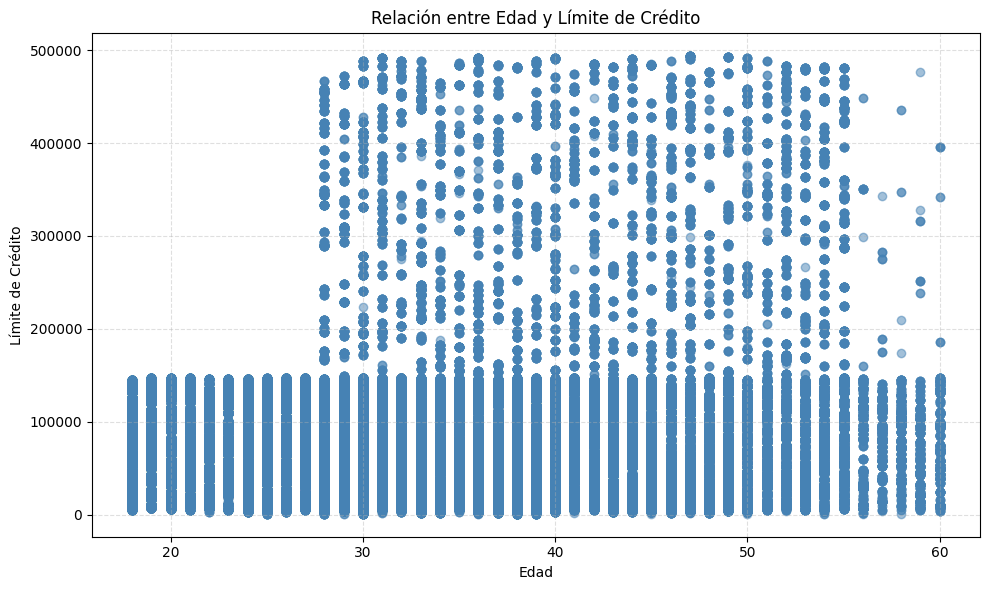

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(pou_exe['edad'], pou_exe['limite_credito'], alpha=0.5, color='steelblue')

plt.title('Relación entre Edad y Límite de Crédito')
plt.xlabel('Edad')
plt.ylabel('Límite de Crédito')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

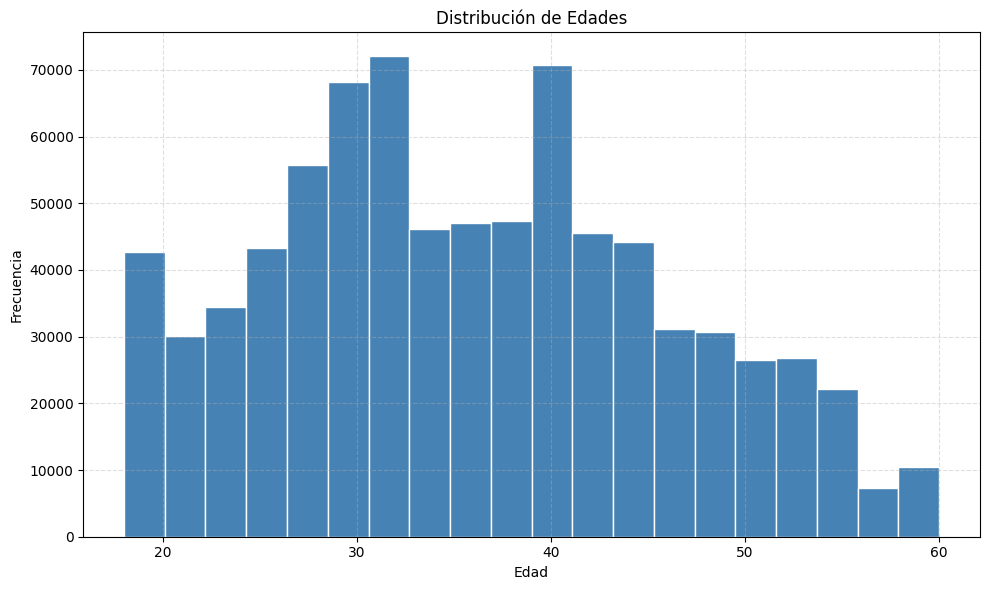

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(pou_exe['edad'], bins=20, color='steelblue', edgecolor='white')

plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [71]:
# Definir los grupos de edad
bins = [0, 30, 45, pou_exe['edad'].max()]
labels = ['Jóvenes (18-30)', 'Adultos (31-45)', 'Tercera Edad (46+)']

pou_exe['grupo_edad'] = pd.cut(pou_exe['edad'], bins=bins, labels=labels)

# Contar y calcular porcentaje
conteo = pou_exe['grupo_edad'].value_counts().sort_index()
porcentaje = (conteo / conteo.sum() * 100).round(2)

resumen_edad = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje': porcentaje
})

print(resumen_edad)

                    Cantidad  Porcentaje
grupo_edad                              
Jóvenes (18-30)       274511       34.21
Adultos (31-45)       372902       46.47
Tercera Edad (46+)    154971       19.31


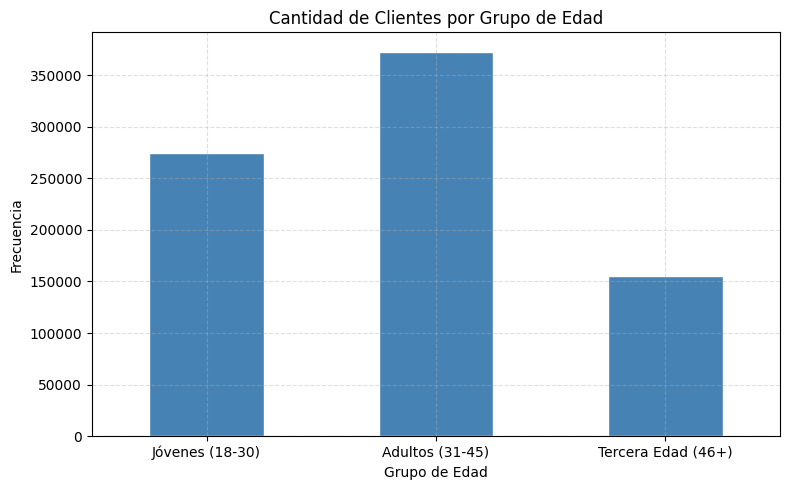

In [72]:
conteo.plot(kind='bar', color='steelblue', edgecolor='white', figsize=(8, 5))
plt.title('Cantidad de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [73]:
# Ver desbalance en todas las variables categóricas
columnas_categoricas = pou_exe.select_dtypes(include=['object', 'category']).columns

resumen_desbalance = {}

for col in columnas_categoricas:
    frecuencias = pou_exe[col].value_counts(normalize=True) * 100
    clase_dominante = frecuencias.iloc[0]
    resumen_desbalance[col] = {
        'clase_dominante': frecuencias.index[0],
        'porcentaje_dominante': round(clase_dominante, 2),
        'num_clases': pou_exe[col].nunique(),
        'desbalanceada': clase_dominante > 80
    }

resumen_desbalance_df = pd.DataFrame(resumen_desbalance).T
print(resumen_desbalance_df.sort_values('porcentaje_dominante', ascending=False))

C:\Users\shdez\AppData\Local\Temp\ipykernel_12748\1014658559.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = pou_exe.select_dtypes(include=['object', 'category']).columns


                                    clase_dominante porcentaje_dominante  \
idioma_preferido                              es_MX                96.71   
estatus                                  completada                93.26   
canal_apertura                                  App                81.26   
tipo_producto                         cuenta_debito                76.52   
ocupacion                                  Empleado                56.56   
sexo                                              M                48.32   
grupo_edad                          Adultos (31-45)                46.47   
preferencia_canal                           app_ios                46.09   
categoria_mcc                         transferencia                45.74   
dispositivo                                 app_ios                44.69   
nivel_educativo                        Licenciatura                43.26   
tipo_operacion                               compra                39.82   
canal       

count    802384.000000
mean       6108.495959
std        9885.308664
min           5.010000
25%         540.000000
50%        1740.000000
75%        7030.937500
max       79511.300000
Name: monto, dtype: float64
Varianza: 97719327.39
Coef. variación: 161.83%


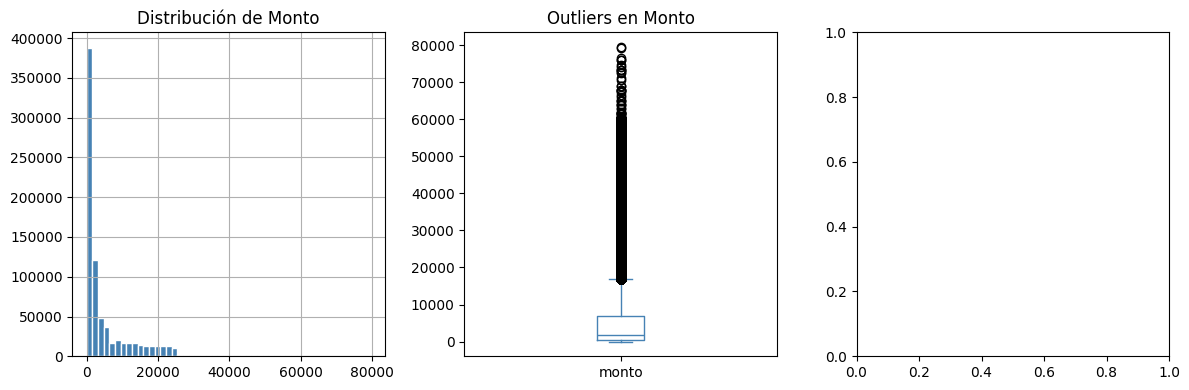

In [74]:
import seaborn as sns

# 1. Estadísticas descriptivas
print(pou_exe['monto'].describe())

# 2. Distribución
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
pou_exe['monto'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de Monto')

# 3. Boxplot para detectar outliers
plt.subplot(1, 3, 2)
pou_exe['monto'].plot(kind='box', color='steelblue')
plt.title('Outliers en Monto')

# 4. Varianza — si es casi cero no aporta al clustering
plt.subplot(1, 3, 3)
print(f'Varianza: {pou_exe["monto"].var():.2f}')
print(f'Coef. variación: {(pou_exe["monto"].std() / pou_exe["monto"].mean() * 100):.2f}%')

plt.tight_layout()
plt.show()

In [75]:
# Ver cantidad de valores únicos
print(f'Valores únicos: {pou_exe["comercio_nombre"].nunique()}')

# Ver las más frecuentes
print(pou_exe['comercio_nombre'].value_counts().head(10))

# Ver qué porcentaje representa el top 10
top10_pct = (pou_exe['comercio_nombre'].value_counts().head(10).sum() / len(pou_exe) * 100).round(2)
print(f'Top 10 comercios representan: {top10_pct}%')

Valores únicos: 75
comercio_nombre
PodcastHub          15483
CloudDrive MX       15481
GamerPass           15418
NewsDigital MX      15409
MusicFlow MX        15401
StreamPlus          15365
Gobierno MX Pago    12389
CFE Digital         12339
Predial MX          12295
IMPI Servicios      12272
Name: count, dtype: int64
Top 10 comercios representan: 17.68%


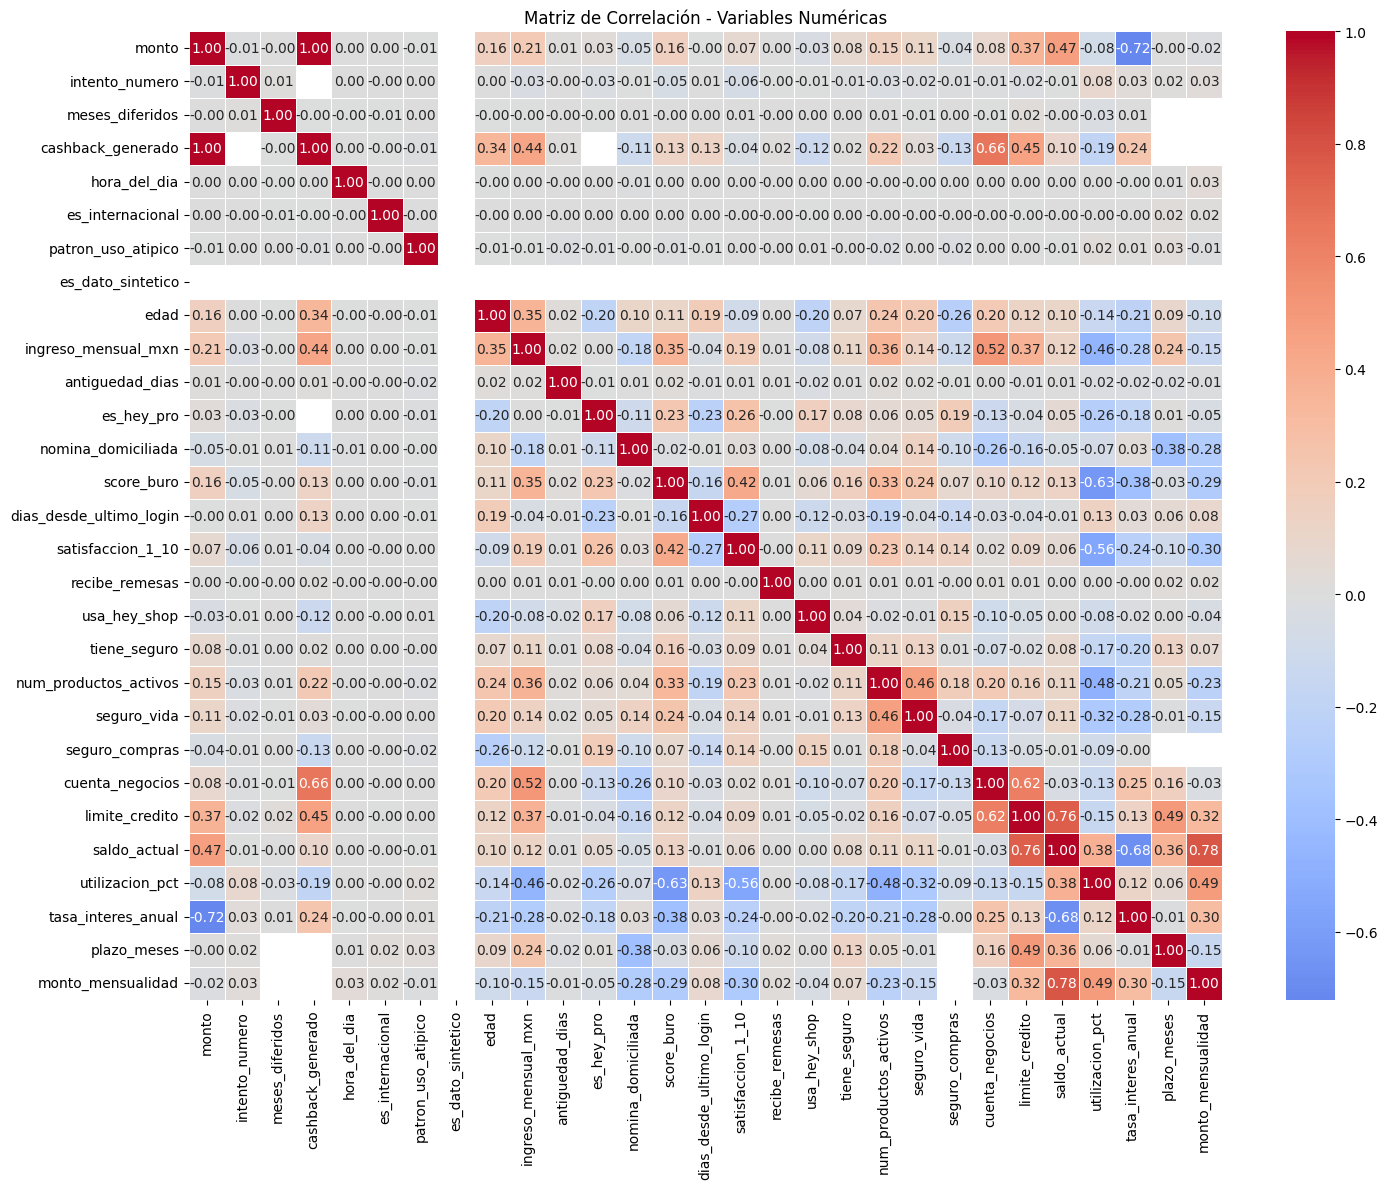

In [76]:
import seaborn as sns

# Seleccionar solo variables numéricas
numericas = pou_exe.select_dtypes(include=['int64', 'float64']).columns

# Matriz de correlación
plt.figure(figsize=(15, 12))
sns.heatmap(
    pou_exe[numericas].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

In [77]:
# Identificar pares con correlación > 0.70
correlacion = pou_exe[numericas].corr()

pares_alta_correlacion = []

for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.70:
            pares_alta_correlacion.append({
                'variable_1': correlacion.columns[i],
                'variable_2': correlacion.columns[j],
                'correlacion': round(correlacion.iloc[i, j], 2)
            })

pares_df = pd.DataFrame(pares_alta_correlacion).sort_values('correlacion', ascending=False)
print(pares_df)

       variable_1          variable_2  correlacion
0           monto   cashback_generado         1.00
3    saldo_actual   monto_mensualidad         0.78
2  limite_credito        saldo_actual         0.76
1           monto  tasa_interes_anual        -0.72


In [78]:
pou_exe

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,tipo_producto,fecha_apertura,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,grupo_edad
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,tarjeta_credito_hey,2022-10-16,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,Jóvenes (18-30)
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,tarjeta_credito_negocios,2025-07-09,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,Tercera Edad (46+)
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,cuenta_debito,2025-09-10,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,Tercera Edad (46+)
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,tarjeta_credito_negocios,2025-07-09,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,Tercera Edad (46+)
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,cuenta_debito,2025-09-10,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,Tercera Edad (46+)


In [79]:
print(f'Valores únicos: {pou_exe["ciudad_transaccion"].nunique()}')

Valores únicos: 93


In [80]:
print(f'Valores únicos: {pou_exe["estado"].nunique()}')

Valores únicos: 17


In [81]:
print(f'Valores únicos: {pou_exe["descripcion_libre"].nunique()}')
print(pou_exe['descripcion_libre'].head(5))

Valores únicos: 36
0    Cargo automático
1    Cargo automático
2             inv hey
3        SPEI enviado
4           dep. efvo
Name: descripcion_libre, dtype: str


In [82]:
# Ver distribución completa
print(pou_exe['descripcion_libre'].value_counts(normalize=True) * 100)

descripcion_libre
ret. cajero         2.813678
SPEI env            2.812733
CARGO RECUR         2.812328
PAG SERV            2.805847
Compra en línea     2.804092
compra tienda       2.803552
Inversion Hey       2.802471
RET CAJERO          2.800176
transf spei         2.797476
compra en lnea      2.796260
inv hey             2.789239
DEP EFECTIVO        2.788969
cobro membresia     2.785324
pago efectuado      2.783839
abono inv           2.783704
Pago Efectuado      2.783434
trnsf SPEI          2.783029
dep. efvo           2.771957
pgo efctuado        2.771822
dep OXXO            2.771687
ret cajero auto     2.771417
Cargo automático    2.770472
SPEI enviado        2.769932
cargo automatico    2.769797
Suscripción dig     2.767366
pago srvc           2.766421
INV HEY             2.765611
crg recur           2.764666
Pago srv            2.761965
srv pago            2.756835
PAGO EFECTUADO      2.754674
SUSCRIP             2.754269
COMPRA TRNDA        2.748193
membresía dig.      2.743

IMputacion de variables

Dropeo de variables

In [83]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# ─── PASO 1: Guardar user_id aparte ──────────────────────
user_ids = pou_exe['user_id'].copy()

# ─── PASO 2: IMPUTACIONES ─────────────────────────────────

# meses_diferidos → 0 significa que no difirió
pou_exe['meses_diferidos'] = pou_exe['meses_diferidos'].fillna(0)

# saldo_actual → 0 significa que no tiene saldo
pou_exe['saldo_actual'] = pou_exe['saldo_actual'].fillna(0)

# cashback_generado → 0 significa que no generó cashback
pou_exe['cashback_generado'] = pou_exe['cashback_generado'].fillna(0)

# monto_mensualidad → 0 significa que no tiene mensualidad
pou_exe['monto_mensualidad'] = pou_exe['monto_mensualidad'].fillna(0)

# limite_credito → mediana por tipo_producto
pou_exe['limite_credito'] = pou_exe.groupby('tipo_producto')['limite_credito'].transform(
    lambda x: x.fillna(x.median())
)
pou_exe['limite_credito'] = pou_exe['limite_credito'].fillna(
    pou_exe['limite_credito'].median()
)

# tasa_interes_anual → mediana por tipo_producto
pou_exe['tasa_interes_anual'] = pou_exe.groupby('tipo_producto')['tasa_interes_anual'].transform(
    lambda x: x.fillna(x.median())
)
pou_exe['tasa_interes_anual'] = pou_exe['tasa_interes_anual'].fillna(
    pou_exe['tasa_interes_anual'].median()
)

# plazo_meses → moda por tipo_producto
pou_exe['plazo_meses'] = pou_exe.groupby('tipo_producto')['plazo_meses'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
)
pou_exe['plazo_meses'] = pou_exe['plazo_meses'].fillna(0)

# utilizacion_pct → recalcular desde saldo y limite
pou_exe['utilizacion_pct'] = np.where(
    (pou_exe['saldo_actual'] == 0) | (pou_exe['limite_credito'] == 0),
    0,
    pou_exe['saldo_actual'] / pou_exe['limite_credito']
)
pou_exe['utilizacion_pct'] = pou_exe['utilizacion_pct'].clip(0, 1)

# satisfaccion_1_10 → moda por estatus y tipo_producto
pou_exe['satisfaccion_1_10'] = pou_exe.groupby(
    ['estatus', 'tipo_producto']
)['satisfaccion_1_10'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
)
pou_exe['satisfaccion_1_10'] = pou_exe['satisfaccion_1_10'].fillna(
    pou_exe['satisfaccion_1_10'].median()
)

# ocupacion → moda global
pou_exe['ocupacion'] = pou_exe['ocupacion'].fillna(
    pou_exe['ocupacion'].mode()[0]
)

# nivel_educativo → moda global
pou_exe['nivel_educativo'] = pou_exe['nivel_educativo'].fillna(
    pou_exe['nivel_educativo'].mode()[0]
)

# sexo → moda global
pou_exe['sexo'] = pou_exe['sexo'].fillna(
    pou_exe['sexo'].mode()[0]
)

# estado → moda global
pou_exe['estado'] = pou_exe['estado'].fillna(
    pou_exe['estado'].mode()[0]
)

# idioma_preferido → moda global
pou_exe['idioma_preferido'] = pou_exe['idioma_preferido'].fillna(
    pou_exe['idioma_preferido'].mode()[0]
)

# comercio_nombre → moda global
pou_exe['comercio_nombre'] = pou_exe['comercio_nombre'].fillna(
    pou_exe['comercio_nombre'].mode()[0]
)

# ciudad_transaccion → moda global
pou_exe['ciudad_transaccion'] = pou_exe['ciudad_transaccion'].fillna(
    pou_exe['ciudad_transaccion'].mode()[0]
)

# ciudad → moda global
pou_exe['ciudad'] = pou_exe['ciudad'].fillna(
    pou_exe['ciudad'].mode()[0]
)

# Verificar nulos
print('Nulos después de imputación:')
nulos = pou_exe.isnull().sum()
print(nulos[nulos > 0])

# ─── PASO 3: TRANSFORMACIONES ─────────────────────────────

# Log transform para variables con sesgo
pou_exe['monto_log']             = np.log1p(pou_exe['monto'])
pou_exe['limite_credito_log']    = np.log1p(pou_exe['limite_credito'])
pou_exe['saldo_actual_log']      = np.log1p(pou_exe['saldo_actual'])
pou_exe['cashback_log']          = np.log1p(pou_exe['cashback_generado'])
pou_exe['monto_mensualidad_log'] = np.log1p(pou_exe['monto_mensualidad'])

# Dias sin movimiento desde fecha
pou_exe['dias_sin_movimiento'] = (
    pd.Timestamp.now() - pd.to_datetime(pou_exe['fecha_ultimo_movimiento'])
).dt.days

# estado → agrupar en regiones
regiones = {
    'Chihuahua'        : 'Norte',
    'Sonora'           : 'Norte',
    'Coahuila'         : 'Norte',
    'Nuevo León'       : 'Norte',
    'Tamaulipas'       : 'Norte',
    'Baja California'  : 'Norte',
    'Ciudad de México' : 'Centro',
    'Estado de México' : 'Centro',
    'Jalisco'          : 'Centro',
    'Puebla'           : 'Centro',
    'Guanajuato'       : 'Centro',
    'Oaxaca'           : 'Sur',
    'Chiapas'          : 'Sur',
    'Veracruz'         : 'Sur',
    'Guerrero'         : 'Sur',
    'Yucatán'          : 'Sur',
    'Quintana Roo'     : 'Sur',
}
pou_exe['region'] = pou_exe['estado'].map(regiones).fillna('Otro')

# idioma_preferido → binario
pou_exe['es_espanol'] = (pou_exe['idioma_preferido'] == 'es_MX').astype(int)

# sexo → binario
pou_exe['es_masculino'] = (pou_exe['sexo'] == 'M').astype(int)

# nivel_educativo → ordinal
nivel_educativo_orden = {
    'Sin estudios' : 0,
    'Primaria'     : 1,
    'Secundaria'   : 2,
    'Preparatoria' : 3,
    'Licenciatura' : 4,
    'Maestría'     : 5,
    'Doctorado'    : 6
}
pou_exe['nivel_educativo_ord'] = pou_exe['nivel_educativo'].map(
    nivel_educativo_orden
).fillna(0).astype(int)

# ocupacion → agrupar en categorías
ocupacion_grupos = {
    'Empleado'      : 'Dependiente',
    'Obrero'        : 'Dependiente',
    'Gobierno'      : 'Dependiente',
    'Empresario'    : 'Independiente',
    'Comerciante'   : 'Independiente',
    'Freelance'     : 'Independiente',
    'Profesionista' : 'Independiente',
    'Estudiante'    : 'Inactivo',
    'Jubilado'      : 'Inactivo',
    'Desempleado'   : 'Inactivo',
    'Ama de casa'   : 'Inactivo',
}
pou_exe['ocupacion_grupo'] = pou_exe['ocupacion'].map(
    ocupacion_grupos
).fillna('Otro')

# ─── PASO 4: DROPEO ───────────────────────────────────────
pou_exe = pou_exe.drop(columns=[
    # IDs
    'user_id',
    'transaccion_id',
    'producto_id',
    # Fechas crudas
    'fecha_hora',
    'fecha_apertura',
    'fecha_ultimo_movimiento',
    # Demográficas reemplazadas por transformadas
    'estado',
    'idioma_preferido',
    'sexo',
    'nivel_educativo',
    'ocupacion',
    # Originales reemplazadas por transformadas
    'monto',
    'limite_credito',
    'saldo_actual',
    'cashback_generado',
    'monto_mensualidad',
])

print(f'\nVariables después de dropeo: {pou_exe.shape[1]}')

# ─── PASO 5: Encoding booleanas ───────────────────────────
columnas_bool = pou_exe.select_dtypes(include='bool').columns
pou_exe[columnas_bool] = pou_exe[columnas_bool].astype(int)

# ─── PASO 6: Encoding categóricas ─────────────────────────

# High cardinality → frecuencia encoding
for col in ['comercio_nombre', 'ciudad_transaccion', 'ciudad']:
    freq = pou_exe[col].value_counts(normalize=True)
    pou_exe[col + '_freq'] = pou_exe[col].map(freq)
    pou_exe = pou_exe.drop(columns=[col])

# One Hot para categóricas con pocas categorías
cols_onehot = ['region', 'ocupacion_grupo']
pou_exe = pd.get_dummies(pou_exe, columns=cols_onehot, drop_first=True)

# Resto de categóricas object
columnas_cat = pou_exe.select_dtypes(include='object').columns
pou_exe = pd.get_dummies(pou_exe, columns=columnas_cat, drop_first=True)

print(f'Variables después de encoding: {pou_exe.shape[1]}')

# ─── PASO 7: Split estratificado ──────────────────────────
pou_exe['estratificacion'] = (
    pou_exe['estatus_en_disputa'].astype(str) + '_' +
    pou_exe['canal_apertura_Fan Shop'].astype(str)
)

X_train, X_val = train_test_split(
    pou_exe,
    test_size=0.2,
    random_state=42,
    stratify=pou_exe['estratificacion']
)

X_train = X_train.drop(columns=['estratificacion'])
X_val   = X_val.drop(columns=['estratificacion'])

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')

# ─── PASO 8: Normalización y Estandarización ──────────────
cols_standard = [
    'ingreso_mensual_mxn',
    'score_buro',
    'monto_log',
    'limite_credito_log',
    'saldo_actual_log',
    'cashback_log',
    'monto_mensualidad_log',
    'tasa_interes_anual'
]

cols_minmax = X_train.select_dtypes(
    include=['float64', 'int64', 'float32']
).columns.difference(cols_standard)

scaler_standard = StandardScaler()
scaler_minmax   = MinMaxScaler()

X_train[cols_standard] = scaler_standard.fit_transform(X_train[cols_standard])
X_val[cols_standard]   = scaler_standard.transform(X_val[cols_standard])

X_train[cols_minmax]   = scaler_minmax.fit_transform(X_train[cols_minmax])
X_val[cols_minmax]     = scaler_minmax.transform(X_val[cols_minmax])

# ─── PASO 9: Limpiar tipos y nulos finales ────────────────
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
X_val   = X_val.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)

print(f'\nNulos finales Train: {X_train.isnull().sum().sum()}')
print(f'Nulos finales Val:   {X_val.isnull().sum().sum()}')
print(f'\nShape final Train: {X_train.shape}')
print(f'Shape final Val:   {X_val.shape}')

Nulos después de imputación:
motivo_no_procesada    775775
descripcion_libre       61752
dispositivo            202063
dtype: int64

Variables después de dropeo: 50


C:\Users\shdez\AppData\Local\Temp\ipykernel_12748\2623797435.py:225: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_cat = pou_exe.select_dtypes(include='object').columns


Variables después de encoding: 138
Train: (641907, 138)
Val:   (160477, 138)

Nulos finales Train: 0
Nulos finales Val:   0

Shape final Train: (641907, 138)
Shape final Val:   (160477, 138)


Generando etiquetas iniciales con K-Means...
Calculando importancia de features...

Top 20 features más importantes:
                        feature  importancia
                   cashback_log     0.162167
                      monto_log     0.120668
            ingreso_mensual_mxn     0.075844
                     score_buro     0.071137
                     es_hey_pro     0.053463
    categoria_mcc_transferencia     0.047295
          tipo_operacion_compra     0.043090
             tasa_interes_anual     0.036469
           comercio_nombre_freq     0.035481
    tipo_producto_inversion_hey     0.035432
               saldo_actual_log     0.023215
   tipo_operacion_transf_salida     0.021375
  tipo_operacion_transf_entrada     0.020131
                cuenta_negocios     0.019571
    tipo_producto_cuenta_debito     0.015716
              satisfaccion_1_10     0.015037
                utilizacion_pct     0.014229
tipo_operacion_cargo_recurrente     0.012406
                           e

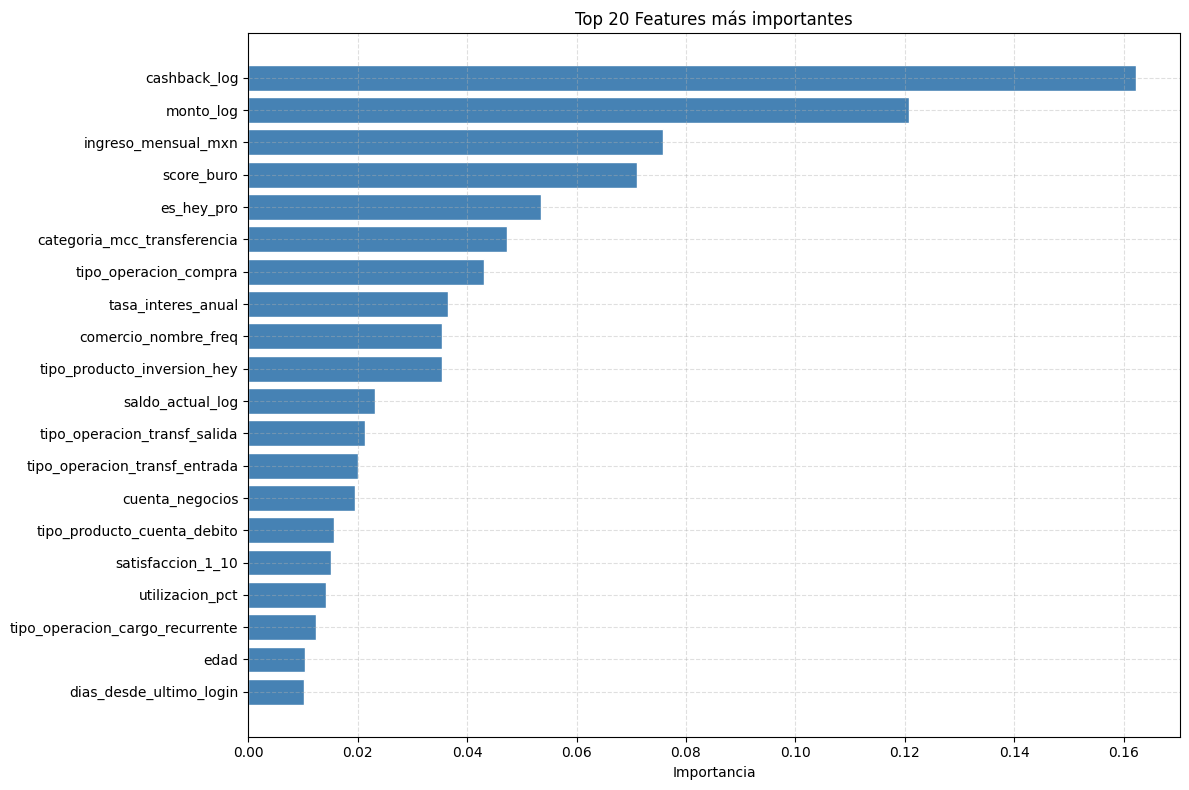


Buscando mejor combinación features + clusters...
  Features: 10 | K: 3 | Silhouette: 0.3010 | Vacíos: 0
  Features: 10 | K: 4 | Silhouette: 0.2779 | Vacíos: 0
  Features: 10 | K: 5 | Silhouette: 0.2805 | Vacíos: 0
  Features: 10 | K: 6 | Silhouette: 0.2713 | Vacíos: 0
  Features: 10 | K: 8 | Silhouette: 0.2619 | Vacíos: 0
  Features: 15 | K: 3 | Silhouette: 0.2494 | Vacíos: 0
  Features: 15 | K: 4 | Silhouette: 0.2302 | Vacíos: 0
  Features: 15 | K: 5 | Silhouette: 0.2271 | Vacíos: 0
  Features: 15 | K: 6 | Silhouette: 0.2102 | Vacíos: 0
  Features: 15 | K: 8 | Silhouette: 0.2126 | Vacíos: 0
  Features: 20 | K: 3 | Silhouette: 0.2040 | Vacíos: 0
  Features: 20 | K: 4 | Silhouette: 0.2143 | Vacíos: 0
  Features: 20 | K: 5 | Silhouette: 0.2212 | Vacíos: 0
  Features: 20 | K: 6 | Silhouette: 0.2046 | Vacíos: 0
  Features: 20 | K: 8 | Silhouette: 0.2005 | Vacíos: 0
  Features: 25 | K: 3 | Silhouette: 0.1804 | Vacíos: 0
  Features: 25 | K: 4 | Silhouette: 0.1922 | Vacíos: 0
  Features: 25

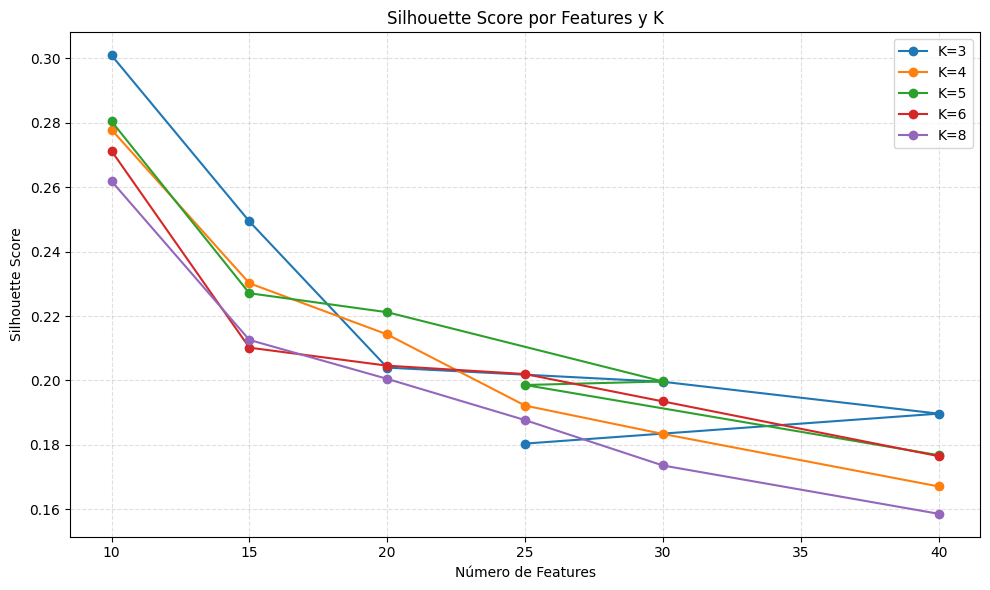


✅ Mejor combinación:
   Features:   10
   K:          3
   Silhouette: 0.301

Mejores features seleccionadas:
['cashback_log', 'monto_log', 'ingreso_mensual_mxn', 'score_buro', 'es_hey_pro', 'categoria_mcc_transferencia', 'tipo_operacion_compra', 'tasa_interes_anual', 'comercio_nombre_freq', 'tipo_producto_inversion_hey']


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── PASO 1: Clustering inicial para etiquetas ────────────
print('Generando etiquetas iniciales con K-Means...')
kmeans_init = KMeans(n_clusters=4, random_state=42, n_init=10)
etiquetas   = kmeans_init.fit_predict(X_train)

# ─── PASO 2: Random Forest para importancia ───────────────
print('Calculando importancia de features...')
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, etiquetas)

importancias = pd.DataFrame({
    'feature'    : X_train.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print('\nTop 20 features más importantes:')
print(importancias.head(20).to_string(index=False))

# ─── PASO 3: Gráfica de importancias ──────────────────────
plt.figure(figsize=(12, 8))
plt.barh(
    importancias.head(20)['feature'][::-1],
    importancias.head(20)['importancia'][::-1],
    color='steelblue', edgecolor='white'
)
plt.title('Top 20 Features más importantes')
plt.xlabel('Importancia')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ─── PASO 4: Búsqueda óptima features + clusters ──────────
print('\nBuscando mejor combinación features + clusters...')

resultados = []

for n_features in [10, 15, 20, 25, 30, 40]:
    top_features = importancias.head(n_features)['feature'].tolist()

    X_train_top = X_train[top_features]
    X_val_top   = X_val[top_features]

    for k in [3, 4, 5, 6, 8]:
        kmeans     = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_train_top)
        clusters_val = kmeans.predict(X_val_top)

        # Solo Silhouette Score
        silhouette = silhouette_score(
            X_val_top, clusters_val, sample_size=5000
        )

        counts = np.bincount(clusters_val, minlength=k)
        vacios = (counts == 0).sum()

        resultados.append({
            'n_features': n_features,
            'k'         : k,
            'silhouette': round(silhouette, 4),
            'vacios'    : vacios
        })

        print(f'  Features: {n_features:2d} | K: {k} | '
              f'Silhouette: {silhouette:.4f} | '
              f'Vacíos: {vacios}')

# ─── PASO 5: Resultados ───────────────────────────────────
resultados_df = pd.DataFrame(resultados).sort_values(
    by=['vacios', 'silhouette'],
    ascending=[True, False]
)

print('\n─── TOP 10 MEJORES COMBINACIONES ───')
print(resultados_df.head(10).to_string(index=False))

# ─── PASO 6: Gráfica Silhouette ───────────────────────────
plt.figure(figsize=(10, 6))
for k in [3, 4, 5, 6, 8]:
    df_k = resultados_df[resultados_df['k'] == k]
    plt.plot(df_k['n_features'], df_k['silhouette'], 'o-', label=f'K={k}')

plt.title('Silhouette Score por Features y K')
plt.xlabel('Número de Features')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ─── PASO 7: Mejor combinación ────────────────────────────
mejor = resultados_df[resultados_df['vacios'] == 0].iloc[0]

print(f'\n✅ Mejor combinación:')
print(f'   Features:   {int(mejor["n_features"])}')
print(f'   K:          {int(mejor["k"])}')
print(f'   Silhouette: {mejor["silhouette"]}')

mejor_n_features = int(mejor['n_features'])
mejor_k          = int(mejor['k'])
mejores_features = importancias.head(mejor_n_features)['feature'].tolist()

print(f'\nMejores features seleccionadas:')
print(mejores_features)

In [85]:
# ============================================================
# EXPORTACIÓN CLUSTERING — SIMPLIFICADA
# ============================================================
import joblib
import os

# ─── Entrenar modelo final ────────────────────────────────
X_train_final = X_train[mejores_features]
X_val_final   = X_val[mejores_features]

kmeans_final  = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
kmeans_final.fit(X_train_final)
clusters_val  = kmeans_final.predict(X_val_final)

# ─── Mapa usuario → cluster ───────────────────────────────
X_val_con_id            = X_val.copy()
X_val_con_id['user_id'] = user_ids.iloc[X_val.index].values
X_val_con_id['cluster'] = clusters_val

mapa_usuario_cluster = dict(
    zip(X_val_con_id['user_id'], X_val_con_id['cluster'])
)

# ─── Desnormalizar X_val ──────────────────────────────────
X_val_desnorm = X_val.copy()

# StandardScaler
cols_std_presentes = [c for c in cols_standard if c in X_val.columns]
if cols_std_presentes:
    X_val_desnorm[cols_std_presentes] = scaler_standard.inverse_transform(
        X_val[cols_std_presentes]
    )

# MinMaxScaler
cols_minmax_train = X_train.select_dtypes(
    include=['float64', 'int64', 'float32']
).columns.difference(cols_standard).tolist()

cols_minmax_presentes = [
    c for c in cols_minmax_train
    if c in X_val.columns
]

if len(cols_minmax_presentes) == scaler_minmax.n_features_in_:
    X_val_desnorm[cols_minmax_presentes] = scaler_minmax.inverse_transform(
        X_val[cols_minmax_presentes]
    )
elif hasattr(scaler_minmax, 'feature_names_in_'):
    cols_orden = [
        c for c in scaler_minmax.feature_names_in_
        if c in X_val.columns
    ]
    X_val_desnorm[cols_orden] = scaler_minmax.inverse_transform(
        X_val[cols_orden]
    )

# Agregar user_id y cluster
X_val_desnorm['user_id'] = user_ids.iloc[X_val.index].values
X_val_desnorm['cluster'] = clusters_val

print(f'✅ Desnormalización completada')
print(f'   Ingreso promedio:    ${X_val_desnorm["ingreso_mensual_mxn"].mean():,.0f} MXN')
print(f'   Score buró promedio: {X_val_desnorm["score_buro"].mean():.0f}')

# ─── Perfiles de clusters ─────────────────────────────────
perfiles_clusters = {}
for c in range(mejor_k):
    mask             = clusters_val == c
    clientes_cluster = X_val_final[mask]
    promedio_global  = X_val_final.mean()
    promedio_cluster = clientes_cluster.mean()

    diferencias = {}
    for feature in mejores_features:
        if promedio_global[feature] != 0:
            diff_pct = (
                promedio_cluster[feature] - promedio_global[feature]
            ) / abs(promedio_global[feature]) * 100
            if abs(diff_pct) > 20:
                diferencias[feature] = round(diff_pct, 1)

    perfiles_clusters[c] = {
        'diferencias': diferencias,
        'promedio'   : promedio_cluster.to_dict(),
        'tamaño'     : int(mask.sum())
    }

# ─── Guardar solo lo necesario ────────────────────────────
joblib.dump(kmeans_final,         'kmeans_heybanco.pkl')
joblib.dump(mejores_features,     'mejores_features.pkl')
joblib.dump(mapa_usuario_cluster, 'mapa_usuario_cluster.pkl')
joblib.dump(perfiles_clusters,    'perfiles_clusters.pkl')
joblib.dump(X_val_desnorm,        'X_val_desnorm.pkl')
joblib.dump(mejor_k,              'mejor_k.pkl')
joblib.dump(mejor_n_features,     'mejor_n_features.pkl')

# ─── Verificar ────────────────────────────────────────────
archivos = [
    'kmeans_heybanco.pkl',
    'mejores_features.pkl',
    'mapa_usuario_cluster.pkl',
    'perfiles_clusters.pkl',
    'X_val_desnorm.pkl',
    'mejor_k.pkl',
    'mejor_n_features.pkl'
]

print('\n─── Archivos exportados ───')
for archivo in archivos:
    existe = os.path.exists(archivo)
    size   = os.path.getsize(archivo) / 1024 if existe else 0
    print(f'  {"✅" if existe else "❌"} {archivo} ({size:.1f} KB)')

print(f'\nResumen:')
print(f'  Mejor K:           {mejor_k}')
print(f'  Mejor features:    {mejor_n_features}')
print(f'  Usuarios mapeados: {len(mapa_usuario_cluster):,}')
for c in range(mejor_k):
    print(f'  Cluster {c}: {perfiles_clusters[c]["tamaño"]:,} clientes')

✅ Desnormalización completada
   Ingreso promedio:    $31,307 MXN
   Score buró promedio: 634

─── Archivos exportados ───
  ✅ kmeans_heybanco.pkl (2508.7 KB)
  ✅ mejores_features.pkl (0.2 KB)
  ✅ mapa_usuario_cluster.pkl (202.4 KB)
  ✅ perfiles_clusters.pkl (1.7 KB)
  ✅ X_val_desnorm.pkl (91060.1 KB)
  ✅ mejor_k.pkl (0.0 KB)
  ✅ mejor_n_features.pkl (0.0 KB)

Resumen:
  Mejor K:           3
  Mejor features:    10
  Usuarios mapeados: 14,797
  Cluster 0: 114,458 clientes
  Cluster 1: 36,110 clientes
  Cluster 2: 9,909 clientes
